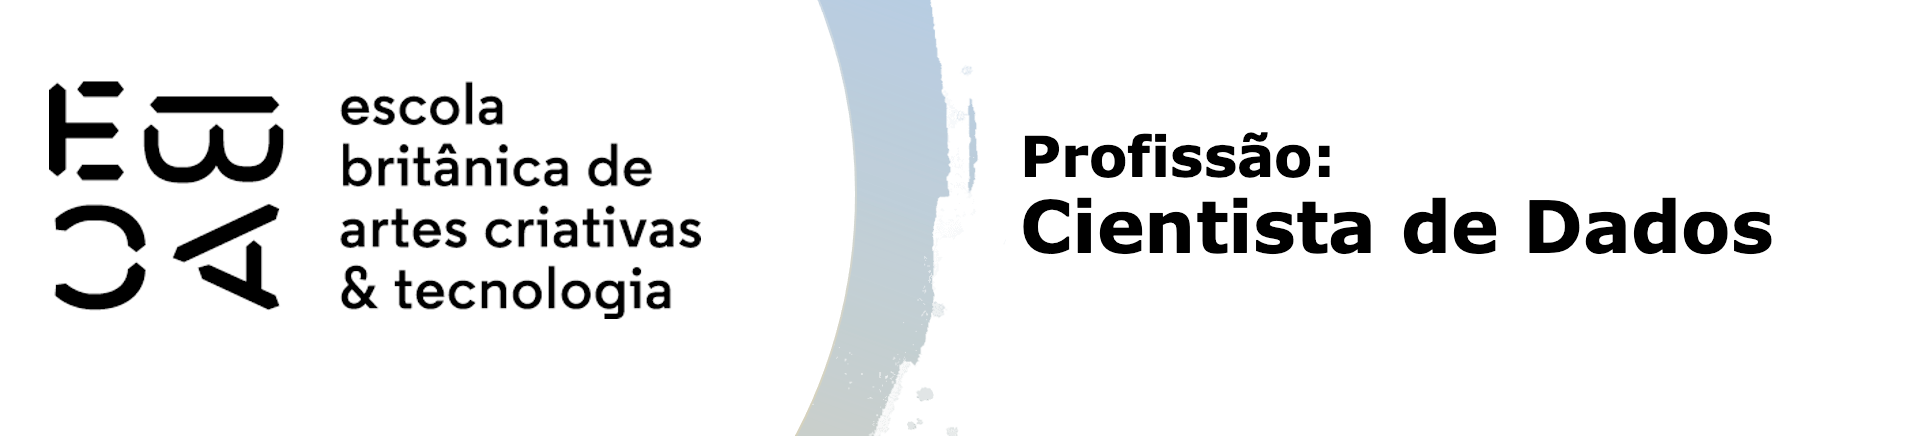

# Tarefa I

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import silhouette_score

df = pd.read_feather('../Mod_35/credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [2]:
data = df[df['data_ref'].dt.year == 2015].copy()
data_unseen = df[df['data_ref'].dt.year == 2016].copy()

print(f'Dimensões dos dados para treino do modelo: {data.shape}\nDimensões dos dados para validação do modelo (OOT): {data_unseen.shape}')

Dimensões dos dados para treino do modelo: (600000, 15)
Dimensões dos dados para validação do modelo (OOT): (150000, 15)


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [3]:
# Classificar variáveis em qualitativas (discretas) e quantitativas (contínuas)
def classificar_variavel(variavel: pd.Series) -> str:
    '''
    Função para classificar uma variável em 'discreta' ou 'contínua'.

    Parâmetros:
    - variavel: recebe uma Serie do Pandas

    Retorna:
    - string identificando a variável
    '''
    try:
        num_classes = variavel.nunique()
        dtype = variavel.dtype
        if num_classes >= 6 and dtype in ['int64', 'float64']:
            return 'contínua'
        else:
            return 'discreta'
    except:
        return 'não identificado'
        

In [4]:
# Criando tabela com metadados
metadata = pd.DataFrame({'dtype': data.dtypes,
                         'num_missings': data.isna().sum(),
                         'num_classes': data.nunique(),
                         'tipo_variavel': [classificar_variavel(data[col]) for col in data],
                         'papel': 'independente'})

# Identificando variáveis que não utilizaremos
metadata.loc[metadata.index == 'data_ref', 'papel'] = 'não usar'
metadata.loc[metadata.index == 'index', 'papel'] = 'não usar'

# Identificando variável dependente
metadata.loc[metadata.index == 'mau', 'papel'] = 'dependente'

# Visualizando resultado
metadata

,dtype,num_missings,num_classes,tipo_variavel,papel
data_ref,datetime64[ns],0,12,discreta,não usar
index,int64,0,16650,contínua,não usar
sexo,object,0,2,discreta,independente
posse_de_veiculo,object,0,2,discreta,independente
posse_de_imovel,object,0,2,discreta,independente
qtd_filhos,int64,0,8,contínua,independente
tipo_renda,object,0,5,discreta,independente
educacao,object,0,5,discreta,independente
estado_civil,object,0,5,discreta,independente
tipo_residencia,object,0,6,discreta,independente


In [5]:
# Visualizando quantidade de registros por mês nos dados
data.groupby(by='data_ref', observed=False)['data_ref'].count()

data_ref
2015-01-01    50000
2015-02-01    50000
2015-03-01    50000
2015-04-01    50000
2015-05-01    50000
2015-06-01    50000
2015-07-01    50000
2015-08-01    50000
2015-09-01    50000
2015-10-01    50000
2015-11-01    50000
2015-12-01    50000
Name: data_ref, dtype: int64

In [6]:
# Definindo funções para conduzir análise univariada
def analise_univariada_quantitativa(variavel: pd.Series) -> None:
    '''
    Função para plotar a análise univariada de uma variável contínua.

    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão
    '''
    tb = pd.DataFrame(variavel.describe().rename({'count': 'contagem', 'mean': 'média', 'std': 'desvio padrão'}))
    display(tb)

    variavel.plot(kind='hist', ylabel='Frequência', title='Histograma de {}'.format(variavel.name.capitalize()))
    plt.show()

def analise_univariada_qualitativa(variavel: pd.Series) -> None:
    '''
    Função para plotar a análise univariada de uma variável discreta.

    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão
    '''
    tb = pd.DataFrame(variavel.value_counts(normalize=True)).rename({'proportion': 'Proporção'}, axis=1)
    display(tb)

    tb.plot(kind='bar', title='Proporção das Classes de {}'.format(variavel.name.capitalize()))
    plt.show()

def analise_univariada(variavel: pd.Series, tipo: str) -> None:
    '''
    Função para conduzir a análise univariada de acordo com o tipo da variável.

    
    Parâmetros:
    - variavel: recebe o Series do Pandas da variável em questão.
    - tipo: recebe o tipo da variável, entre 'discreta' e 'contínua'.
    '''
    if tipo not in ['discreta', 'contínua']:
        return 'Tipo da variável não aceito'
    if tipo == 'discreta':
        return analise_univariada_qualitativa(variavel)
    return analise_univariada_quantitativa(variavel)

,Proporção
sexo,
F,0.673008
M,0.326992


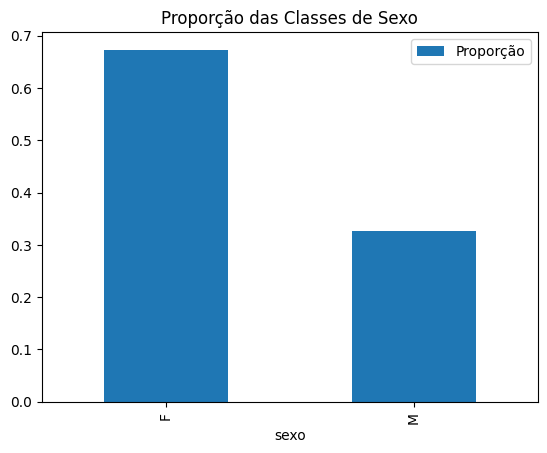

,Proporção
posse_de_veiculo,
N,0.610488
S,0.389512


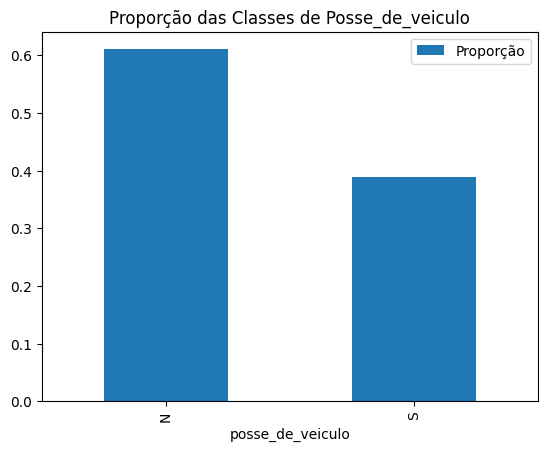

,Proporção
posse_de_imovel,
S,0.671757
N,0.328243


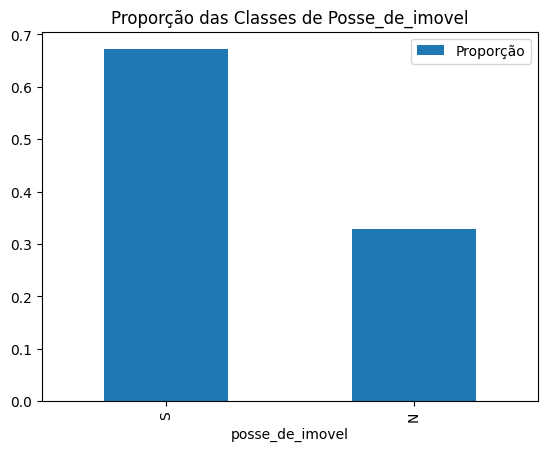

,qtd_filhos
contagem,600000.000000
média,0.433210
desvio padrão,0.739869
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,14.000000


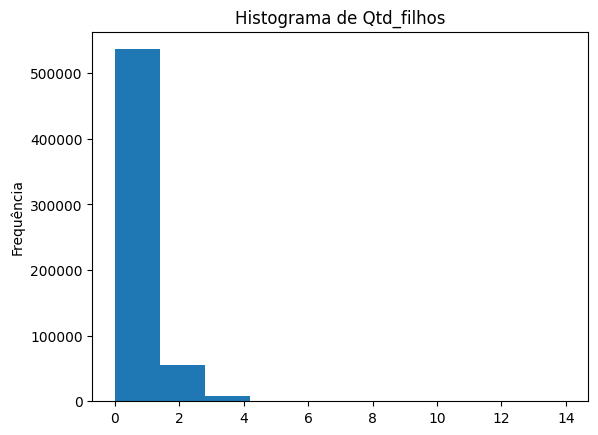

,Proporção
tipo_renda,
Assalariado,0.514100
Empresário,0.230235
Pensionista,0.168545
Servidor público,0.086635
Bolsista,0.000485


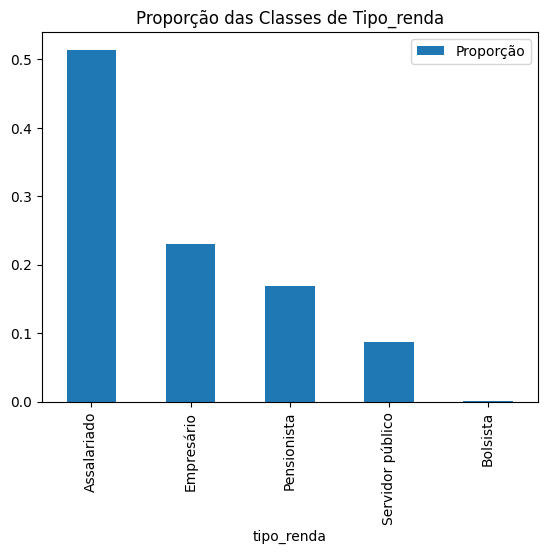

,Proporção
educacao,
Médio,0.675748
Superior completo,0.272400
Superior incompleto,0.039265
Fundamental,0.011502
Pós graduação,0.001085


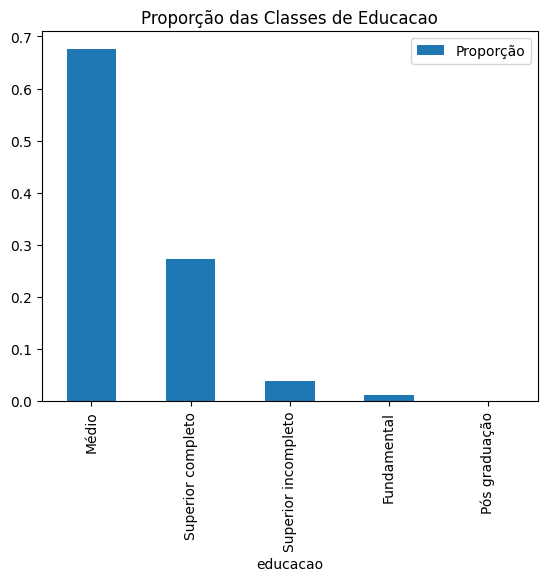

,Proporção
estado_civil,
Casado,0.701915
Solteiro,0.122035
União,0.076847
Separado,0.056980
Viúvo,0.042223


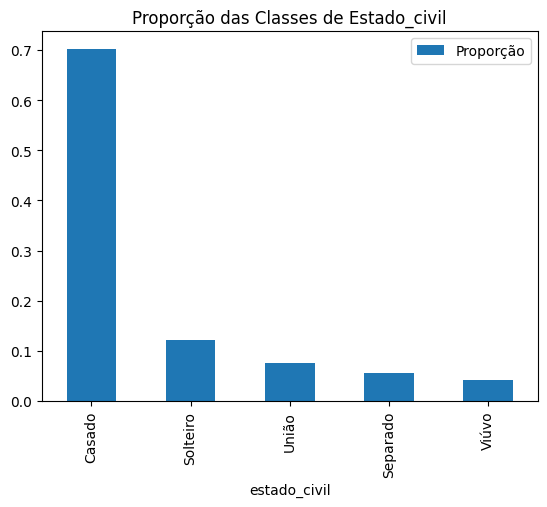

,Proporção
tipo_residencia,
Casa,0.898893
Com os pais,0.044550
Governamental,0.031237
Aluguel,0.013770
Estúdio,0.007160
Comunitário,0.004390


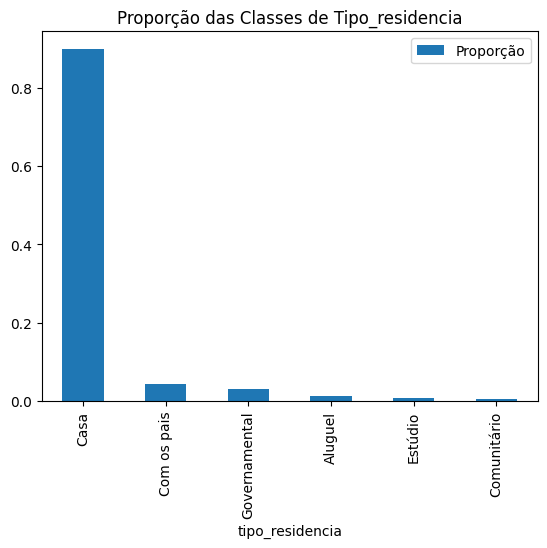

,idade
contagem,600000.000000
média,43.798530
desvio padrão,11.230659
min,22.000000
25%,34.000000
50%,43.000000
75%,53.000000
max,68.000000


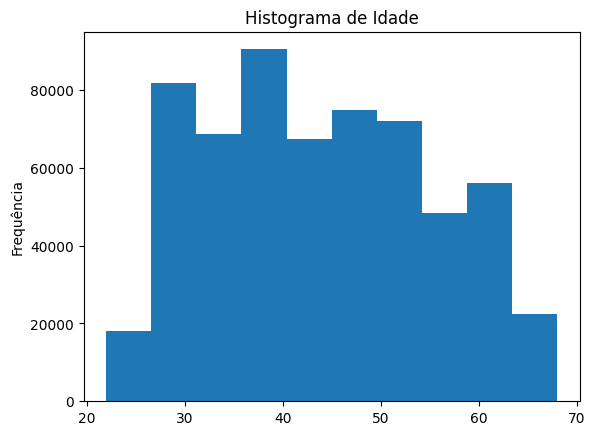

,tempo_emprego
contagem,499125.000000
média,7.747992
desvio padrão,6.688576
min,0.117808
25%,3.049315
50%,6.046575
75%,10.180822
max,42.906849


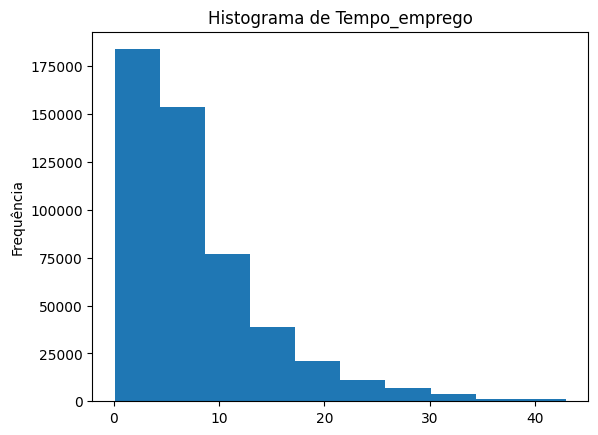

,qt_pessoas_residencia
contagem,600000.000000
média,2.212122
desvio padrão,0.903757
min,1.000000
25%,2.000000
50%,2.000000
75%,3.000000
max,15.000000


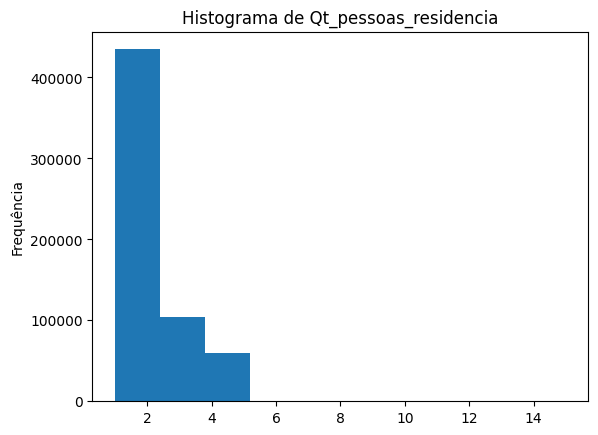

,renda
contagem,6.000000e+05
média,2.722284e+04
desvio padrão,8.737788e+04
min,1.618600e+02
25%,4.670600e+03
50%,9.887580e+03
75%,2.162887e+04
max,4.083986e+06


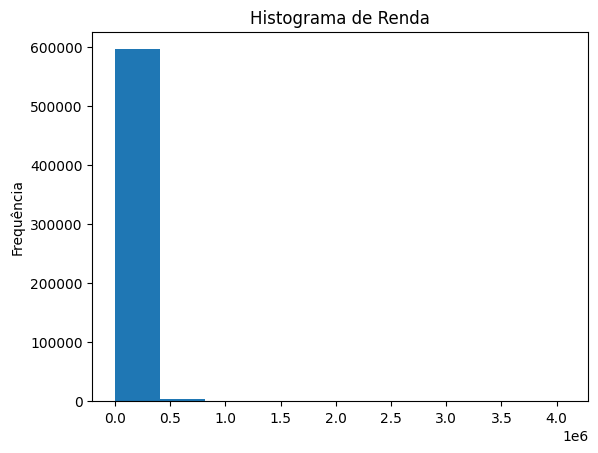

In [7]:
# Realizando análise univariada por cada variável na base de dados
for col in data:
    if metadata[metadata.index == col]['papel'].iloc[0] != 'independente':
        continue
    else:
        tipo =  metadata[metadata.index == col]['tipo_variavel'].iloc[0]
        analise_univariada(data[col], tipo)

## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

In [8]:
# Definindo funções para conduzir análise bivariada (independente x dependente) por cada variável na base de dados
def categorizar_variavel(variavel: pd.Series) -> pd.Series:
    '''
    Função para categorizar uma variável contínua de forma a permitir a análise bivariada

    Parâmetros:
    - variavel: uma Series do Pandas, sendo essa a variável a ser categorizada
    '''
    labels = pd.qcut(variavel, 10, duplicates='drop')
    cat_variavel = pd.Series(labels, name=f'cat_{variavel.name}')
    return cat_variavel

def analise_bivariada(variavel: pd.Series, resposta: pd.Series) -> None:
    '''
    Função para conduzir uma análise bivariada com base nos cálculos de Weight of Evidence (WOE) e Information Value (IV) das variáveis.

    Parâmetros:
    - variavel: uma Series do Pandas, sendo essa a variável a ser estudada
    - resposta: uma Series do Pandas, sendo essa a variável resposta binária a se usar como base
    '''
    tab = pd.crosstab(variavel, resposta, margins=True)
    tab['Prop_nao_evento'] = tab[0] / tab[0].sum()
    tab['Prop_evento'] = tab[1] / tab[1].sum()

    epsilon = 1e-10
    tab['WOE'] = np.log((tab['Prop_nao_evento'] + epsilon) / (tab['Prop_evento'] + epsilon))
    tab['IV_parcial'] = (tab['Prop_nao_evento'] - tab['Prop_evento']) * tab['WOE']

    iv = tab['IV_parcial'].sum()

    display(tab)
    print(f'Information Value (IV) da variável {variavel.name}: {iv:.4%}')

    tab['WOE'].drop('All').plot(kind='barh', xlabel='Weight of Evidence', title=f'WOE por Classe da Variável {variavel.name.capitalize()}')
    plt.show()

def calcular_iv(variavel: pd.Series, resposta: pd.Series) -> float:
    '''
    Função para calcular o Information Value (IV) da variável.

    Parâmetros:
    - variavel: uma Series do Pandas, sendo essa a variável a ser estudada
    - resposta: uma Series do Pandas, sendo essa a variável resposta binária a se usar como base

    Retorna:
    - Information Value
    '''
    tab = pd.crosstab(variavel, resposta, margins=True)
    tab['Prop_nao_evento'] = tab[0] / tab[0].sum()
    tab['Prop_evento'] = tab[1] / tab[1].sum()

    epsilon = 1e-10
    tab['WOE'] = np.log((tab['Prop_nao_evento'] + epsilon) / (tab['Prop_evento'] + epsilon))
    tab['IV_parcial'] = (tab['Prop_nao_evento'] - tab['Prop_evento']) * tab['WOE']

    iv = tab['IV_parcial'].sum()
    return iv

def classificar_iv(iv: float) -> str:
    '''
    Função para classificar o IV de acordo com a classificação mais usada para contexto de credit score.

    Parâmetros:
    - iv: o valor de Information Value da variável

    Retorna:
    - Classificação de IV
    '''
    if iv < 0.02:
        return 'Inútil'
    elif 0.02 <= iv < 0.1:
        return 'Fraca'
    elif 0.1 <= iv < 0.3:
        return 'Média'
    elif 0.3 <= iv < 0.5:
        return 'Forte'
    return 'Sobreajuste'

Análise Bivariada da Variável Sexo


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
sexo,,,,,,,
F,378318,25487,403805,0.335771,0.347774,-0.035125,0.000422
M,185039,11156,196195,0.164229,0.152226,0.075898,0.000911
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável sexo: 0.1333%


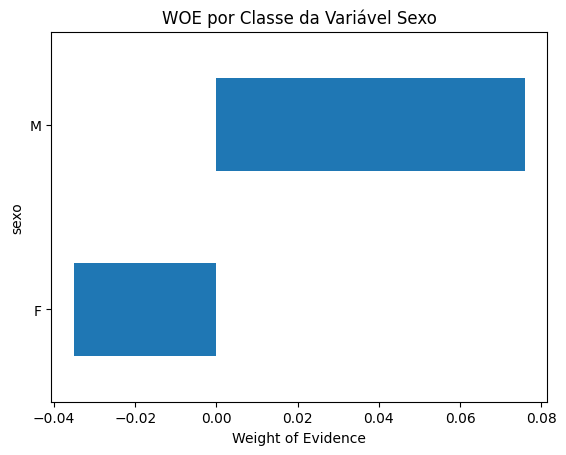

Análise Bivariada da Variável Posse_de_veiculo


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
posse_de_veiculo,,,,,,,
N,343778,22515,366293,0.305116,0.307221,-0.006877,0.000014
S,219579,14128,233707,0.194884,0.192779,0.010862,0.000023
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável posse_de_veiculo: 0.0037%


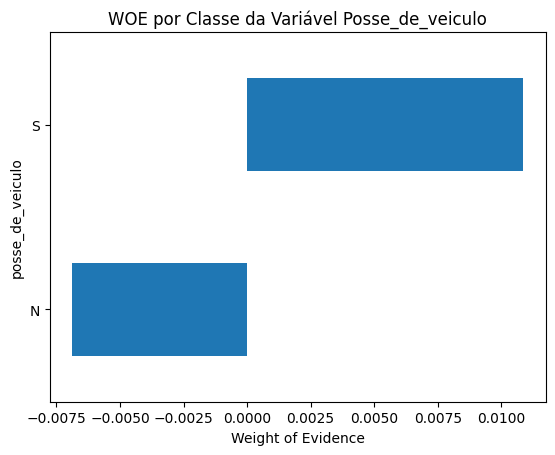

Análise Bivariada da Variável Posse_de_imovel


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
posse_de_imovel,,,,,,,
N,183305,13641,196946,0.16269,0.186134,-0.134620,0.003156
S,380052,23002,403054,0.33731,0.313866,0.072036,0.001689
All,563357,36643,600000,0.50000,0.500000,0.000000,0.000000


Information Value (IV) da variável posse_de_imovel: 0.4845%


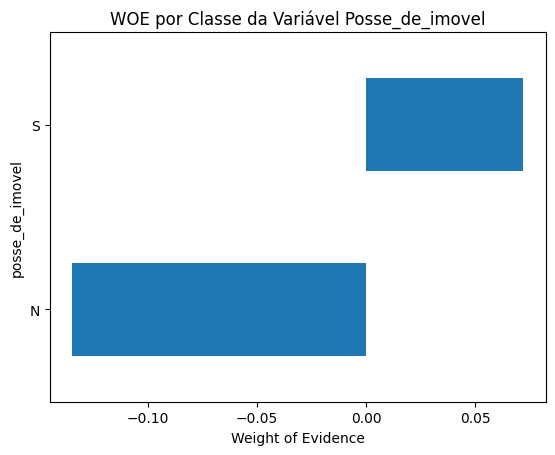

Análise Bivariada da Variável Qtd_filhos


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_qtd_filhos,,,,,,,
"(-0.001, 1.0]",503676,32677,536353,0.447031,0.445883,0.002571,0.000003
"(1.0, 2.0]",52182,3421,55603,0.046313,0.046680,-0.007886,0.000003
"(2.0, 14.0]",7499,545,8044,0.006656,0.007437,-0.110952,0.000087
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável cat_qtd_filhos: 0.0092%


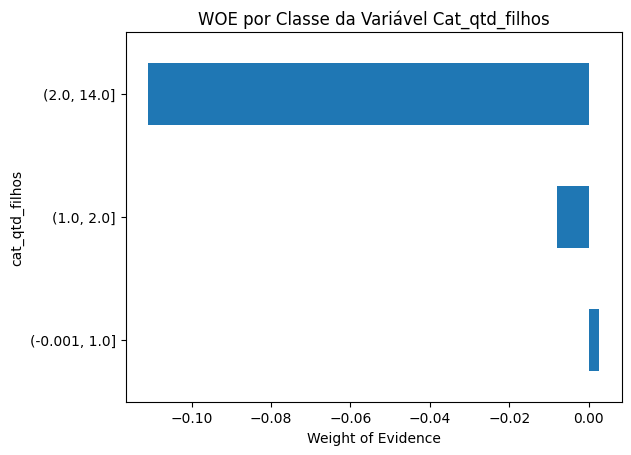

Análise Bivariada da Variável Tipo_renda


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
tipo_renda,,,,,,,
Assalariado,288865,19595,308460,0.256378,0.267377,-0.042006,0.000462
Bolsista,279,12,291,0.000248,0.000164,0.413614,0.000035
Empresário,129935,8206,138141,0.115322,0.111972,0.029478,0.000099
Pensionista,94627,6500,101127,0.083985,0.088694,-0.054550,0.000257
Servidor público,49651,2330,51981,0.044067,0.031793,0.326459,0.004007
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável tipo_renda: 0.4859%


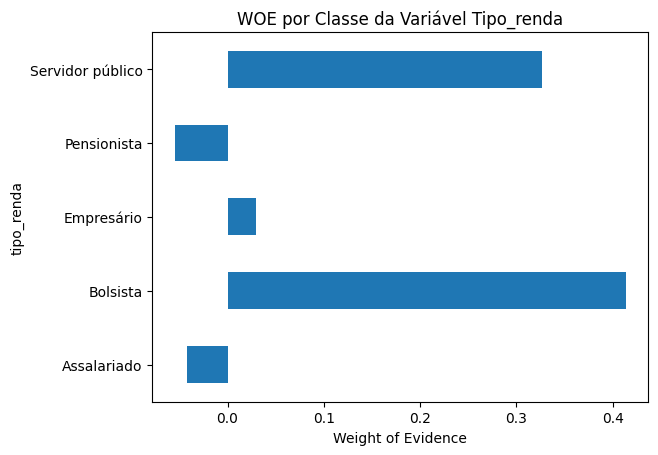

Análise Bivariada da Variável Educacao


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
educacao,,,,,,,
Fundamental,6420,481,6901,0.005698,0.006563,-0.141385,0.000122
Médio,379939,25510,405449,0.337210,0.348088,-0.031751,0.000345
Pós graduação,608,43,651,0.000540,0.000587,-0.083716,0.000004
Superior completo,154354,9086,163440,0.136995,0.123980,0.099823,0.001299
Superior incompleto,22036,1523,23559,0.019558,0.020782,-0.060696,0.000074
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável educacao: 0.1845%


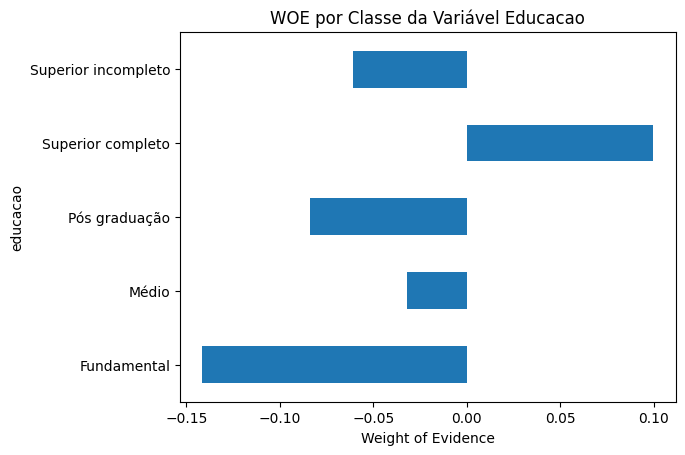

Análise Bivariada da Variável Estado_civil


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
estado_civil,,,,,,,
Casado,395880,25269,421149,0.351358,0.344800,0.018842,0.000124
Separado,31994,2194,34188,0.028396,0.029938,-0.052869,0.000082
Solteiro,68585,4636,73221,0.060872,0.063259,-0.038469,0.000092
União,43048,3060,46108,0.038207,0.041754,-0.088790,0.000315
Viúvo,23850,1484,25334,0.021168,0.020249,0.044352,0.000041
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável estado_civil: 0.0653%


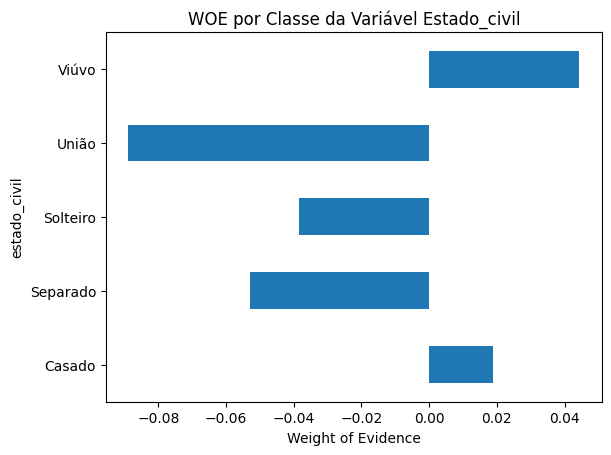

Análise Bivariada da Variável Tipo_residencia


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
tipo_residencia,,,,,,,
Aluguel,7666,596,8262,0.006804,0.008133,-0.178382,0.000237
Casa,506887,32449,539336,0.449881,0.442772,0.015927,0.000113
Com os pais,24733,1997,26730,0.021951,0.027249,-0.216199,0.001145
Comunitário,2449,185,2634,0.002174,0.002524,-0.149612,0.000052
Estúdio,4071,225,4296,0.003613,0.003070,0.162852,0.000088
Governamental,17551,1191,18742,0.015577,0.016251,-0.042373,0.000029
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000


Information Value (IV) da variável tipo_residencia: 0.1665%


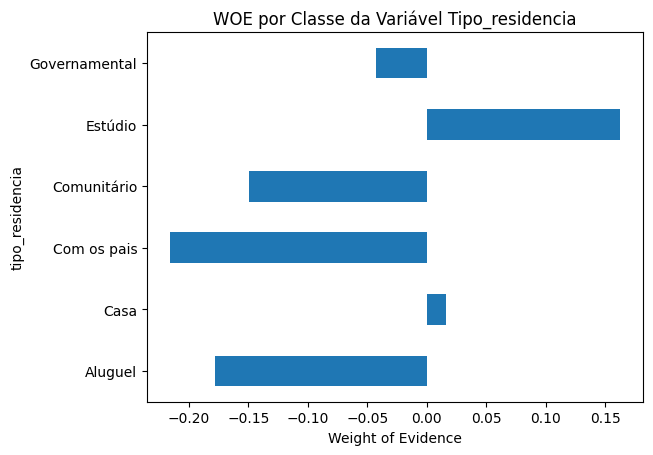

Análise Bivariada da Variável Idade


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_idade,,,,,,,
"(21.999, 29.0]",61628,5356,66984,0.054697,0.073084,-0.289792,0.005328
"(29.0, 33.0]",63496,4655,68151,0.056355,0.063518,-0.119656,0.000857
"(33.0, 36.0]",46010,3079,49089,0.040836,0.042013,-0.028437,0.000033
"(36.0, 40.0]",69989,4624,74613,0.062118,0.063095,-0.015613,0.000015
"(40.0, 43.0]",49264,2852,52116,0.043724,0.038916,0.116482,0.000560
"(43.0, 47.0]",59192,3618,62810,0.052535,0.049368,0.062174,0.000197
"(47.0, 51.0]",55222,2916,58138,0.049012,0.039789,0.208457,0.001922
"(51.0, 55.0]",49126,2696,51822,0.043601,0.036787,0.169928,0.001158
"(55.0, 60.0]",61785,3708,65493,0.054836,0.050596,0.080477,0.000341


Information Value (IV) da variável cat_idade: 1.0420%


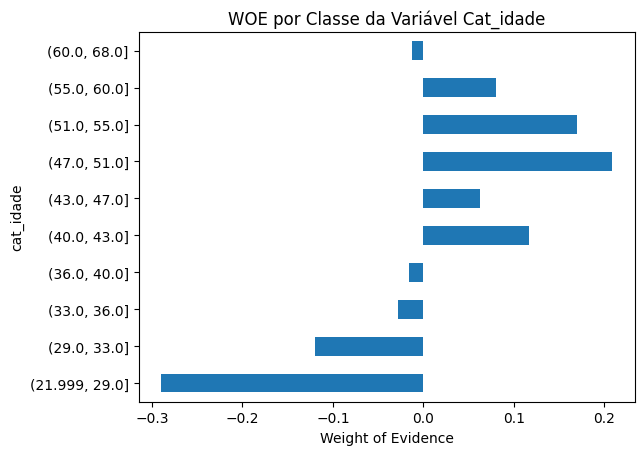

Análise Bivariada da Variável Tempo_emprego


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_tempo_emprego,,,,,,,
"(0.11699999999999999, 1.195]",44598,5510,50108,0.047550,0.091331,-0.652711,0.028576
"(1.195, 2.364]",45006,4770,49776,0.047985,0.079065,-0.499386,0.015521
"(2.364, 3.63]",45691,4257,49948,0.048715,0.070562,-0.370499,0.008094
"(3.63, 4.693]",46190,3830,50020,0.049247,0.063484,-0.253937,0.003615
"(4.693, 6.047]",46750,3339,50089,0.049844,0.055346,-0.104692,0.000576
"(6.047, 7.458]",46944,2685,49629,0.050051,0.044505,0.117440,0.000651
"(7.458, 9.093]",47612,2315,49927,0.050763,0.038372,0.279840,0.003468
"(9.093, 11.726]",48265,1960,50225,0.051460,0.032488,0.459927,0.008726
"(11.726, 16.545]",48567,1057,49624,0.051782,0.017520,1.083674,0.037128


Information Value (IV) da variável cat_tempo_emprego: 19.5608%


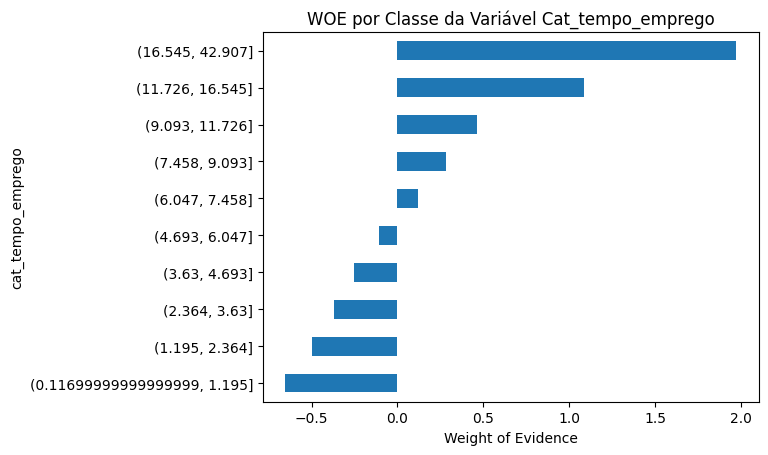

Análise Bivariada da Variável Qt_pessoas_residencia


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_qt_pessoas_residencia,,,,,,,
"(0.999, 2.0]",408788,26050,434838,0.362814,0.355457,0.020488,1.507418e-04
"(2.0, 3.0]",97323,6803,104126,0.086378,0.092828,-0.072019,4.645519e-04
"(3.0, 4.0]",50051,3263,53314,0.044422,0.044524,-0.002296,2.343734e-07
"(4.0, 15.0]",7195,527,7722,0.006386,0.007191,-0.118750,9.561501e-05
All,563357,36643,600000,0.500000,0.500000,0.000000,0.000000e+00


Information Value (IV) da variável cat_qt_pessoas_residencia: 0.0711%


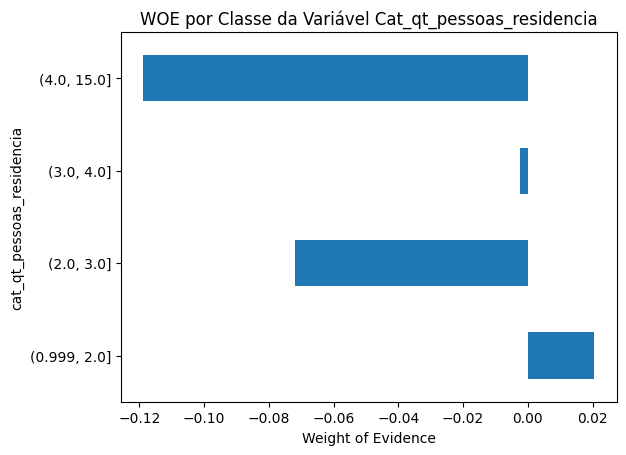

Análise Bivariada da Variável Renda


mau,False,True,All,Prop_nao_evento,Prop_evento,WOE,IV_parcial
cat_renda,,,,,,,
"(161.859, 2450.919]",46939,13061,60000,0.041660,0.178220,-1.453473,0.198486
"(2450.919, 3905.11]",53265,6738,60003,0.047275,0.091941,-0.665175,0.029711
"(3905.11, 5513.49]",55227,4780,60007,0.049016,0.065224,-0.285680,0.004630
"(5513.49, 7430.69]",56458,3533,59991,0.050109,0.048208,0.038659,0.000073
"(7430.69, 9887.58]",57236,2764,60000,0.050799,0.037715,0.297813,0.003897
"(9887.58, 13152.38]",57901,2103,60004,0.051389,0.028696,0.582679,0.013223
"(13152.38, 18064.01]",58428,1570,59998,0.051857,0.021423,0.884028,0.026905
"(18064.01, 26666.57]",58888,1114,60002,0.052265,0.015201,1.234989,0.045774
"(26666.57, 49048.516]",59274,721,59995,0.052608,0.009838,1.676596,0.071707


Information Value (IV) da variável cat_renda: 52.8433%


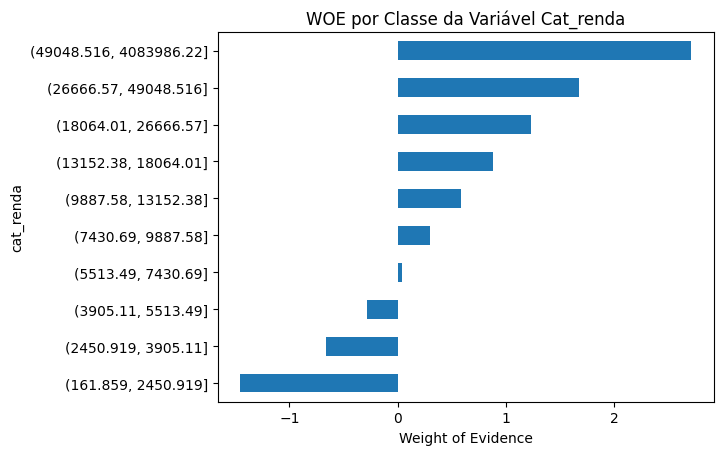

In [9]:
for col in data.drop(['data_ref', 'index', 'mau'], axis=1):
    print(f'Análise Bivariada da Variável {col.capitalize()}')
    if metadata.loc[col, 'tipo_variavel'] == 'contínua':
        analise_bivariada(categorizar_variavel(data[col]), data['mau'])
    else:
        analise_bivariada(data[col], data['mau'])
    print('=' * 120)

In [10]:
# Calculando e salvando Information Value e classificação nos metadados
metadata['IV'] = 0.0
metadata['classificação_IV'] = ''

for indx in metadata.index.drop(['data_ref', 'index', 'mau']):
    iv = calcular_iv(data[indx], data['mau'])
    metadata.loc[indx, 'IV'] = iv
    metadata.loc[indx, 'classificação_IV'] = classificar_iv(iv)

metadata

,dtype,num_missings,num_classes,tipo_variavel,papel,IV,classificação_IV
data_ref,datetime64[ns],0,12,discreta,não usar,0.000000,
index,int64,0,16650,contínua,não usar,0.000000,
sexo,object,0,2,discreta,independente,0.001333,Inútil
posse_de_veiculo,object,0,2,discreta,independente,0.000037,Inútil
posse_de_imovel,object,0,2,discreta,independente,0.004845,Inútil
qtd_filhos,int64,0,8,contínua,independente,0.000844,Inútil
tipo_renda,object,0,5,discreta,independente,0.004859,Inútil
educacao,object,0,5,discreta,independente,0.001845,Inútil
estado_civil,object,0,5,discreta,independente,0.000653,Inútil
tipo_residencia,object,0,6,discreta,independente,0.001665,Inútil


## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [11]:
# Substituindo dados missings com média
data.fillna(value=data['tempo_emprego'].mean(), inplace=True)
data.isna().sum()

data_ref                 0
index                    0
sexo                     0
posse_de_veiculo         0
posse_de_imovel          0
qtd_filhos               0
tipo_renda               0
educacao                 0
estado_civil             0
tipo_residencia          0
idade                    0
tempo_emprego            0
qt_pessoas_residencia    0
renda                    0
mau                      0
dtype: int64

In [12]:
# Fazendo downsampling para balancear a base de dados entre bons e maus pagadores (50/50)
events_data = data[data['mau'] == True]
not_events_data = data[data['mau'] == False]

sample_not_events = not_events_data.sample(n=len(events_data), random_state=412)

data_balanced = pd.concat([events_data, sample_not_events]).sample(frac=1, random_state=412).reset_index(drop=True)

data_balanced.mau.value_counts(normalize=True)

mau
False    0.5
True     0.5
Name: proportion, dtype: float64

In [13]:
data_balanced.shape

(73286, 15)

## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

# a - Criar um pipeline utilizando o sklearn pipeline para o preprocessamento 

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

# b - Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [4]:
import pandas as pd

df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [ ]:
from pycaret.classification import *
models()

In [ ]:
xxx = create_model('xxx')